<a href="https://colab.research.google.com/github/qszy303/KWK-ML-Challenge-2025/blob/main/SMB_Loans_and_Local_Economic_Indicators%2C_Unpredictability_(KWK_Machine_Learning_x_Finance_Challenge).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prediction & Unpredictability: Investigating Which Local Economic Indicators Determine Small Business Loans Across Congressional Districts of the United States

To understand what the columns/predictors mean for the IRS data, refer to [this document](https://docs.google.com/document/d/1XS6fCfKlTgeAQqn35OoUpKKpxMi3kqk7/edit?usp=sharing&ouid=113066592990900930020&rtpof=true&sd=true) for what each column means.

**[IMPORTANT] Read Before Running:** Download [this file](https://docs.google.com/spreadsheets/d/1WxamBEwZinT2BWsp-BIf231S6PY3kc8S/edit?usp=sharing&ouid=113066592990900930020&rtpof=true&sd=true) before running as it's the important Small Business Association (SBA) lender activity by Congressional District in 2022 data.

In [ ]:
import pandas as pd
from scipy import stats
import os

In [ ]:
import pandas as pd

#testing to make sure we have column names right and it's readable
#this is the census zip code data, necessary to convert the zip codes to congressional districts since
url = "https://www2.census.gov/geo/docs/maps-data/data/rel2020/cd-sld/tab20_cd11820_zcta520_natl.txt"
df = pd.read_csv(url, sep='|', dtype=str, nrows=5)
print("Column names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Column names:
['OID_CD118_20', 'GEOID_CD118_20', 'NAMELSAD_CD118_20', 'AREALAND_CD118_20', 'AREAWATER_CD118_20', 'MTFCC_CD118_20', 'FUNCSTAT_CD118_20', 'OID_ZCTA5_20', 'GEOID_ZCTA5_20', 'NAMELSAD_ZCTA5_20', 'AREALAND_ZCTA5_20', 'AREAWATER_ZCTA5_20', 'MTFCC_ZCTA5_20', 'CLASSFP_ZCTA5_20', 'FUNCSTAT_ZCTA5_20', 'AREALAND_PART', 'AREAWATER_PART']

First few rows:
       OID_CD118_20 GEOID_CD118_20         NAMELSAD_CD118_20  \
0  2119031807777901           0101  Congressional District 1   
1  2119031807777901           0101  Congressional District 1   
2  2119031807777901           0101  Congressional District 1   
3  2119031807777901           0101  Congressional District 1   
4  2119031807777901           0101  Congressional District 1   

  AREALAND_CD118_20 AREAWATER_CD118_20 MTFCC_CD118_20 FUNCSTAT_CD118_20  \
0       14843688153         2267935444          G5200                 N   
1       14843688153         2267935444          G5200                 N   
2       14843688153         2

In [ ]:
import pandas as pd
import requests
from io import StringIO, BytesIO
import zipfile

#this is important to make sure the information is stored in a unified location metric (congressional districts)

class ZipToCongressConverter:

  def __init__(self):
    self.lookup_dict = {}
    self.df = None
    self.data_source_used = None

  def load_census_zcta_cd_relationship(self, congress='118'):

    # using congressional data 118

    print(f"Loading Census {congress}th Congress ZCTA relationship file")

    #online url for each year
    url = f"https://www2.census.gov/geo/docs/maps-data/data/rel2020/cd-sld/tab20_cd{congress}20_zcta520_natl.txt"

    try:
        self.df = pd.read_csv(url, sep='|', dtype=str)

        cd_col = f'GEOID_CD{congress}_20'
        zcta_col = 'GEOID_ZCTA5_20'

        for _, row in self.df.iterrows():
          zipcode = str(row[zcta_col]).zfill(5)
          cd_geoid = str(row[cd_col])

          state_fips = cd_geoid[:2]
          district = cd_geoid[2:].lstrip('0') or '0'

          state = self._fips_to_state(state_fips)

          if zipcode not in self.lookup_dict:
              self.lookup_dict[zipcode] = {
                  'state': state,
                  'districts': []
              }

          district_code = f"{state} - {district.zfill(2)}"
          if district_code not in self.lookup_dict[zipcode]['districts']:
              self.lookup_dict[zipcode]['districts'].append(district_code)

        self.data_source_used = f'Census {congress}th Congress ZCTA Relationship File'
        print(f"✓ Loaded {len(self.lookup_dict)} ZIP codes from Census data")
        return True

    #if not found or problem with loading
    except Exception as e:
      print(f"Error loading Census data: {e}")
      return False

  def _fips_to_state(self, fips):
    #converts FIPS code to state abbreviation
      fips_map = {
          '01': 'AL', '02': 'AK', '04': 'AZ', '05': 'AR', '06': 'CA',
          '08': 'CO', '09': 'CT', '10': 'DE', '11': 'DC', '12': 'FL',
          '13': 'GA', '15': 'HI', '16': 'ID', '17': 'IL', '18': 'IN',
          '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME',
          '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS',
          '29': 'MO', '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH',
          '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND',
          '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', '44': 'RI',
          '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT',
          '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI',
          '56': 'WY', '72': 'PR'
      }
      return fips_map.get(fips, fips)

  def lookup(self, zipcode):
    #looks up congressional district for zip code
    zipcode = str(zipcode).zfill(5)
    return self.lookup_dict.get(zipcode)

  def batch_lookup(self, zipcodes):
    #looking up zip codes
    return {zip: self.lookup(zip) for zip in zipcodes}

  def add_to_dataframe(self, df, zipcode_column='zipcode'):
    #adds congressional district columns to DataFrame
    df = df.copy()

    results = df[zipcode_column].apply(lambda z: self.lookup(z))

    df['state'] = results.apply(lambda x: x['state'] if x else None)
    df['congressional_district'] = results.apply(
      lambda x: ', '.join(x['districts']) if x else None
    )

    df['num_districts'] = results.apply(
      lambda x: len(x['districts']) if x else 0
    )

    df['data_source'] = self.data_source_used

    return df

In [ ]:
converter = ZipToCongressConverter()
converter.load_census_zcta_cd_relationship(congress='118')

Loading Census 118th Congress ZCTA relationship file
✓ Loaded 33792 ZIP codes from Census data


True

In [ ]:
print(converter.lookup('21042'))
#looking up some zip codes to check if it works as intended
test_df = pd.DataFrame({'zipcode': ['94720', '10001', '21042']})
enriched = converter.add_to_dataframe(test_df)
print(enriched)

{'state': 'MD', 'districts': ['MD - 03']}
  zipcode state congressional_district  num_districts  \
0   94720    CA                CA - 12              1   
1   10001    NY                NY - 12              1   
2   21042    MD                MD - 03              1   

                                    data_source  
0  Census 118th Congress ZCTA Relationship File  
1  Census 118th Congress ZCTA Relationship File  
2  Census 118th Congress ZCTA Relationship File  


In [ ]:
import pandas as pd
import requests
from io import BytesIO
import zipfile

class IRSCongressionalDataProcessor:

  #processing the IRS data
  def __init__(self):
    self.converter = ZipToCongressConverter()
    self.irs_data = None
    self.enriched_data = None
    self.district_aggregated = None

  def download_irs_data(self, year=2022):


    # url with IRS data
    url = f"https://www.irs.gov/pub/irs-soi/zipcode{year}.zip"

    try:
      response = requests.get(url)
      response.raise_for_status()

      # extract the zip file
      with zipfile.ZipFile(BytesIO(response.content)) as z:
          # find the main csv file (22zpallagi.csv)
          csv_files = [f for f in z.namelist() if f.endswith('.csv')]

          if not csv_files:
              print("No CSV files found in ZIP")
              return False

          # use the first csv (main data file)
          main_file = csv_files[0]
          print(f"  Extracting: {main_file}")

          with z.open(main_file) as f:
              # IRS files use specific encoding
              self.irs_data = pd.read_csv(f, encoding='latin1', dtype={'zipcode': str}, low_memory=False)

      # clean up zip code column (+ensure 5 digits)
      if 'zipcode' in self.irs_data.columns:
          self.irs_data['zipcode'] = self.irs_data['zipcode'].astype(str).str.zfill(5)
      elif 'ZIPCODE' in self.irs_data.columns:
          self.irs_data.rename(columns={'ZIPCODE': 'zipcode'}, inplace=True)
          self.irs_data['zipcode'] = self.irs_data['zipcode'].astype(str).str.zfill(5)

      print(f"Loaded {len(self.irs_data):,} records from IRS data")
      print(f"  Columns ({len(self.irs_data.columns)}): {self.irs_data.columns.tolist()[:10]}...")
      return True

    except Exception as e:
      print(f"Error downloading IRS data: {e}")
      return False

  def map_to_congressional_districts(self, congress='118'):

    if self.irs_data is None:
      print("No IRS data loaded. Run download_irs_data() first.")
      return False

    print(f"\nMapping to {congress}th Congressional Districts...")

    # load congressional district mapping
    if not self.converter.load_census_zcta_cd_relationship(congress=congress):
      return False

    # add congressional district info
    self.enriched_data = self.converter.add_to_dataframe(
      self.irs_data,
      zipcode_column='zipcode'
    )

    # summary stats:
    total_records = len(self.enriched_data)
    matched_records = self.enriched_data['state'].notna().sum()
    unmatched_records = total_records - matched_records

    print(f"\nMapping complete!")
    print(f" Total records: {total_records:,}")
    print(f" Matched: {matched_records:,} ({matched_records/total_records*100:.1f}%)")
    print(f" Unmatched: {unmatched_records:,} ({unmatched_records/total_records*100:.1f}%)")

    return True

  def aggregate_by_district(self):

    if self.enriched_data is None:
      print("✗ No enriched data available. Run map_to_congressional_districts() first.")
      return False

    print("\nAggregating data by congressional district...")

    # filter out unmatched records (some zip codes with multiple districts but there's a lot already so we don't really need to account for them)
    matched_data = self.enriched_data[self.enriched_data['congressional_district'].notna()].copy()

    # find numeric columns to aggregate (sum)
    numeric_cols = matched_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # remove columns we don't want to sum
    exclude_cols = ['num_districts']
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

    # group by congressional district and aggregate
    agg_dict = {col: 'sum' for col in numeric_cols}
    agg_dict['zipcode'] = 'count' #zips in each district

    self.district_aggregated = matched_data.groupby('congressional_district').agg(agg_dict).reset_index()

    # rename zipcode # column
    self.district_aggregated.rename(columns={'zipcode': 'num_zipcodes'}, inplace=True)

    # add state column (extract from district code)
    self.district_aggregated['state'] = self.district_aggregated['congressional_district'].str.split('-').str[0]

    # reorder columns: district, state, num_zipcodes, then all other data
    cols = ['congressional_district', 'state', 'num_zipcodes'] + [col for col in self.district_aggregated.columns if col not in ['congressional_district', 'state', 'num_zipcodes']]
    self.district_aggregated = self.district_aggregated[cols]

    print(f"\nAggregated into {len(self.district_aggregated)} congressional districts")

    return True

  #creating and saving the aggregate data
  def save_by_district(self, filename='irs_by_congressional_district.csv'):

    if self.district_aggregated is None:
      print("No aggregated data to save. Run aggregate_by_district() first.")
      return False

    self.district_aggregated.to_csv(filename, index=False)
    print(f"\nDistrict-aggregated data saved to: {filename}")
    print(f"  Size: {len(self.district_aggregated):,} districts × {len(self.district_aggregated.columns)} columns")
    return True

  def save_detailed_data(self, filename='irs_detailed_with_districts.csv'):

    if self.enriched_data is None:
      print("No enriched data to save. Run map_to_congressional_districts() first.")
      return False

    self.enriched_data.to_csv(filename, index=False)
    print(f"\nDetailed data saved to: {filename}")
    print(f"  Size: {len(self.enriched_data):,} ZIP codes × {len(self.enriched_data.columns)} columns")
    return True

  def process_all(self, year=2022, congress='119', output_by_district='irs_by_congressional_district.csv', output_detailed='irs_detailed_with_districts.csv'):

    print("-•-" * 40)
    print(f"IRS ZIP Code Data → Congressional District Mapper")
    print("-•-" * 40)

    # download IRS data
    if not self.download_irs_data(year=year):
      return False

    # map to congresssional districts
    if not self.map_to_congressional_districts(congress=congress):
      return False

    # aggregate by district
    if not self.aggregate_by_district():
      return False

    # saving
    if not self.save_by_district(filename=output_by_district):
      return False

    if not self.save_detailed_data(filename=output_detailed):
      return False

    print("\n" + "=" * 70)
    print("✓ COMPLETE! Your data is ready.")
    print("=" * 70)

    return True

def calculate_financial_statistics(processor):

  #calculating mean/median/mode/stdev of each district in business income, self-employment tax, number of schedule c filers, and business income % of total agi

  if processor.district_aggregated is None:
    print("Run process_all() first")
    return None

  df = processor.district_aggregated.copy()

  #creating columns of relevant metrics
  business_income_col = None
  business_count_col = None
  self_employment_col = None
  total_agi_col = None
  total_returns_col = None

  for col in df.columns:
    if 'A00900' in col:
      business_income_col = col
    elif 'N00900' in col:
      business_count_col = col
    elif 'A09400' in col:
      self_employment_col = col
    elif 'A00100' in col:
      total_agi_col = col
    elif col == 'N1':
      total_returns_col = col

  found_cols = {
    'Business Income': business_income_col,
    'Business Count': business_count_col,
    'Self-Employment Tax': self_employment_col,
    'Total AGI': total_agi_col,
    'Total Returns': total_returns_col
  }

  print("\nFound columns:")
  for name, col in found_cols.items():
    print(f"  {name}: {col if col else 'NOT FOUND'}")

  if not business_income_col:
    print("\n✗ Business income column not found. Available columns:")
    print([col for col in df.columns if 'A0' in col][:30])
    return None

  #filter out districts with no data
  analysis_df = df.copy()
  if business_count_col:
    analysis_df = analysis_df[analysis_df[business_count_col] > 0].copy()

  #calculate derived metrics
  if business_income_col and business_count_col:
    analysis_df['business_income_per_filer'] = (
        analysis_df[business_income_col] / analysis_df[business_count_col] * 1000
    )

  if self_employment_col and business_count_col:
    analysis_df['self_employment_per_filer'] = (
        analysis_df[self_employment_col] / analysis_df[business_count_col] * 1000
    )

  if business_income_col and total_agi_col:
    analysis_df['business_income_pct_of_agi'] = (
        analysis_df[business_income_col] / analysis_df[total_agi_col] * 100
    ).replace([float('inf'), -float('inf')], 0)

  if business_count_col and total_returns_col:
    analysis_df['pct_returns_with_business'] = (
        analysis_df[business_count_col] / analysis_df[total_returns_col] * 100
    )

  #creating comprehensive stats dataframe
  stats = {
    'metric': [],
    'unit': [],
    'mean': [],
    'median': [],
    'mode': [],
    'std_dev': [],
    'min': [],
    'max': [],
    'q1_25th': [],
    'q3_75th': [],
    'districts_with_data': []
  }

  def add_stats(metric_name, unit, series):
    clean_series = series.dropna()
    if len(clean_series) == 0:
        return

    stats['metric'].append(metric_name)
    stats['unit'].append(unit)
    stats['mean'].append(clean_series.mean())
    stats['median'].append(clean_series.median())
    mode_val = clean_series.mode()
    stats['mode'].append(mode_val.iloc[0] if len(mode_val) > 0 else None)
    stats['std_dev'].append(clean_series.std())
    stats['min'].append(clean_series.min())
    stats['max'].append(clean_series.max())
    stats['q1_25th'].append(clean_series.quantile(0.25))
    stats['q3_75th'].append(clean_series.quantile(0.75))
    stats['districts_with_data'].append(len(clean_series))

  #add stats for each measurement
  if business_income_col:
    add_stats('Total Business Income per District', '$1,000s', analysis_df[business_income_col])

  if business_count_col:
    add_stats('Number of Schedule C Filers per District', 'Count', analysis_df[business_count_col])

  if self_employment_col:
    add_stats('Total Self-Employment Tax per District', '$1,000s', analysis_df[self_employment_col])

  if 'business_income_per_filer' in analysis_df.columns:
    add_stats('Business Income per Filer', '$', analysis_df['business_income_per_filer'])

  if 'self_employment_per_filer' in analysis_df.columns:
    add_stats('Self-Employment Tax per Filer', '$', analysis_df['self_employment_per_filer'])

  if 'business_income_pct_of_agi' in analysis_df.columns:
    add_stats('Business Income as % of Total AGI', '%', analysis_df['business_income_pct_of_agi'])

  if 'pct_returns_with_business' in analysis_df.columns:
    add_stats('% of Returns with Business Income', '%', analysis_df['pct_returns_with_business'])

  stats_df = pd.DataFrame(stats)

  #detailed breakdown of the metrics
  detail_cols = ['congressional_district', 'state']

  if business_income_col:
    detail_cols.append(business_income_col)
  if business_count_col:
    detail_cols.append(business_count_col)
  if self_employment_col:
    detail_cols.append(self_employment_col)
  if total_agi_col:
    detail_cols.append(total_agi_col)

  calculated_cols = [
    'business_income_per_filer',
    'self_employment_per_filer',
    'business_income_pct_of_agi',
    'pct_returns_with_business'
  ]

  for col in calculated_cols:
    if col in analysis_df.columns:
      detail_cols.append(col)

  district_details = analysis_df[detail_cols].copy()

  rename_map = {}
  if business_income_col:
      rename_map[business_income_col] = 'total_business_income_thousands'
  if business_count_col:
      rename_map[business_count_col] = 'num_schedule_c_filers'
  if self_employment_col:
      rename_map[self_employment_col] = 'total_self_employment_thousands'
  if total_agi_col:
      rename_map[total_agi_col] = 'total_agi_thousands'

  district_details.rename(columns=rename_map, inplace=True)

  #add percentile for key metrics
  if 'business_income_per_filer' in district_details.columns:
    district_details['percentile_income_per_filer'] = (
      district_details['business_income_per_filer'].rank(pct=True) * 100
    )

  if 'business_income_pct_of_agi' in district_details.columns:
    district_details['percentile_biz_pct_of_agi'] = (
      district_details['business_income_pct_of_agi'].rank(pct=True) * 100
    )

  if 'pct_returns_with_business' in district_details.columns:
    district_details['percentile_entrepreneurship_rate'] = (
      district_details['pct_returns_with_business'].rank(pct=True) * 100
    )

  #sort by business income % of agi to show economic importance
  if 'business_income_pct_of_agi' in district_details.columns:
    district_details = district_details.sort_values('business_income_pct_of_agi', ascending=False)

  return {
    'summary_statistics': stats_df,
    'district_details': district_details,
    'num_districts_analyzed': len(analysis_df)
  }

def add_financial_stats(processor_class):

  def get_financial_stats(self):

    if self.district_aggregated is None:
      print("No aggregated data")
      return None
    result = calculate_financial_statistics(self)

    if result:
      print("\n" + "-•-" *40)
      print("COMPREHENSIVE BUSINESS STATISTICS ACROSS ALL CONGRESSIONAL DISTRICTS")
      print("-•-" * 40)
      print(result['summary_statistics'].to_string(index=False))
      print(f"\nTotal districts analyzed: {result['num_districts_analyzed']}")
    return result

  def save_financial_stats(self, output_prefix = 'comprehensive_business_stats'):

    result = self.get_financial_stats()

    if result:
      # saving summary statistics
      result['summary_statistics'].to_csv(f'{output_prefix}_summary.csv', index=False)
      print(f"\nSummary statistics saved to: {output_prefix}_summary.csv")

      # saving detailed district breakdown
      result['district_details'].to_csv(f'{output_prefix}_by_district.csv', index=False)
      print(f"District details saved to: {output_prefix}_by_district.csv")

      # print key insights
      district_details = result['district_details']

      print("\n" + "=" * 80)
      print("TOP 10 DISTRICTS BY BUSINESS INCOME AS % OF AGI (Most Business-Dependent)")
      print("=" * 80)

      if 'business_income_pct_of_agi' in district_details.columns:
        top_cols = ['congressional_district', 'state', 'business_income_pct_of_agi',
                    'num_schedule_c_filers', 'business_income_per_filer']
        available_cols = [c for c in top_cols if c in district_details.columns]
        print(district_details[available_cols].head(10).to_string(index=False))

      print("\n" + "=" * 80)
      print("TOP 10 DISTRICTS BY ENTREPRENEURSHIP RATE (% with Business Income)")
      print("=" * 80)
      if 'pct_returns_with_business' in district_details.columns:
        sorted_by_rate = district_details.sort_values('pct_returns_with_business', ascending=False)
        rate_cols = ['congressional_district', 'state', 'pct_returns_with_business',
                    'num_schedule_c_filers', 'business_income_per_filer']
        available_cols = [c for c in rate_cols if c in sorted_by_rate.columns]
        print(sorted_by_rate[available_cols].head(10).to_string(index=False))

      return True

    return False

  # add methods to the class
  processor_class.get_financial_stats = get_financial_stats
  processor_class.save_financial_stats = save_financial_stats

  return processor_class

# apply the enhancement
IRSCongressionalDataProcessor = add_financial_stats(IRSCongressionalDataProcessor)


In [ ]:
# The functionality of this cell has been merged into cell jJXgK1eAitf- to ensure proper class definition.
pass

In [ ]:
def merge_data(irs_file, sba_file):
  # loading files
  irs_df = pd.read_csv(irs_file)
  sba_df = pd.read_excel(sba_file, sheet_name='SBA_LenderActivity_2022.xlsx')

  if 'State' in sba_df.columns and 'District' in sba_df.columns:
      sba_df['congressional_district'] = (
        sba_df['State'].str.upper() + '-' +
        sba_df['District'].astype(str).str.zfill(2)
      )

  # merge on congressional district
  merged_df = irs_df.merge(
    sba_df,
    on='congressional_district',
    how='left',  # keep all IRS districts even if no SBA data
    suffixes=('_irs', '_sba')
  )

  print(f"Merged {len(merged_df)} districts")
  print(f"  Districts with SBA data: {merged_df['sba_column'].notna().sum()}")  # Replace with actual SBA column

  return merged_df


# enhanced processor with SBA data
class EnhancedIRSProcessor(IRSCongressionalDataProcessor):

  def __init__(self):
    super().__init__()
    self.sba_data = None
    self.merged_data = None

  def load_sba_data(self, filepath, sheet_name='Congressional\nDistrict'):
    """Load SBA lending data by congressional district."""
    print(f"Loading SBA data from: {filepath}")

    try:
      self.sba_data = pd.read_excel(filepath, sheet_name=sheet_name)

      # standardize district format
      if 'State' in self.sba_data.columns and 'District' in self.sba_data.columns:
        self.sba_data['congressional_district'] = (
          self.sba_data['State'].str.upper() + '-' +
          self.sba_data['District'].astype(str).str.zfill(2)
        )

      print(f"Loaded SBA data: {len(self.sba_data)} districts")
      return True

    except Exception as e:
      print(f"Error loading SBA data: {e}")
      return False

  def merge_with_sba(self):
    """Merge IRS and SBA data by congressional district."""
    if self.district_aggregated is None:
      print("Run process_all() first to get IRS data")
      return False

    if self.sba_data is None:
      print("Run load_sba_data() first")
      return False

    print("\nMerging IRS and SBA data...")

    self.merged_data = self.district_aggregated.merge(
      self.sba_data,
      on='congressional_district',
      how='left',
      suffixes=('_irs', '_sba')
    )

    sba_coverage = self.merged_data.notna().sum(axis=1).mean()
    print(f"Merged {len(self.merged_data)} districts")

    return True

  def save_merged_data(self, filename='irs_sba_merged.csv'):
    if self.merged_data is None:
      print("Run merge_with_sba() first")
      return False

    self.merged_data.to_csv(filename, index=False)
    print(f"Saved merged data: {filename}")
    return True

In [ ]:
def merge_irs_sba_simple(processor, sba_filepath='SBA_LenderActivity_2022.xlsx', sheet_name=None):

    print("=" * 70)
    print("LOADING SBA DATA")
    print("=" * 70)

    # load SBA Excel file
    try:
      xl = pd.ExcelFile(sba_filepath)
      print(f"Available sheets: {xl.sheet_names}")

      # Auto-detect sheet - PRIORITIZE sheets with "CongDist" or "Congressional"
      if sheet_name is None:
        # Try these patterns in order of preference
        for pattern in ['congdist', 'congressional', 'district', 'congress']:
          for sheet in xl.sheet_names:
            if pattern in sheet.lower():
              sheet_name = sheet
              break
          if sheet_name:
              break

        # Fallback to first sheet if nothing found
        if sheet_name is None:
            sheet_name = xl.sheet_names[0]
            print(f"⚠ Using first sheet: {sheet_name}")

        print(f"Loading sheet: {sheet_name}")
        sba_df = pd.read_excel(sba_filepath, sheet_name=sheet_name)

        print(f"✓ Loaded {len(sba_df)} rows")
        print(f"Raw columns (before cleaning): {sba_df.columns.tolist()}")

        # DON'T clean column names yet - we need to find the column first

    except Exception as e:
        print(f"✗ Error loading SBA file: {e}")
        return None

    # Find the Congressional District column - check for the EXACT name with \n
    district_col = None

    # Check for "Congressional\nDistrict" exactly
    if 'Congressional\nDistrict' in sba_df.columns:
      district_col = 'Congressional\nDistrict'
      print(f"✓ Found exact column: 'Congressional\\nDistrict'")
    else:
        # Try other variations
        for col in sba_df.columns:
            # Check if column contains both "Congress" and "District"
            if 'Congress' in str(col) and 'District' in str(col):
                district_col = col
                print(f"✓ Found column: {repr(col)}")
                break

    if district_col is None:
        print("\n✗ Congressional District column not found!")
        print(f"Available columns: {sba_df.columns.tolist()}")
        print("\nColumn representations:")
        for col in sba_df.columns:
            print(f"  {repr(col)}")
        return None

    # NOW clean all column names (replace \n with space)
    sba_df.columns = [col.replace('\n', ' ').strip() for col in sba_df.columns]

    # Update district_col name after cleaning
    district_col_cleaned = district_col.replace('\n', ' ').strip()

    # Rename to match IRS format
    sba_df.rename(columns={district_col_cleaned: 'congressional_district'}, inplace=True)

    print(f"\n✓ Renamed '{district_col_cleaned}' → 'congressional_district'")
    print(f"Sample values: {sba_df['congressional_district'].head(10).tolist()}")
    print(f"Unique districts in SBA data: {sba_df['congressional_district'].nunique()}")
    print(f"Missing districts: {sba_df['congressional_district'].isna().sum()}")

    print("\n" + "=" * 70)
    print("MERGING IRS AND SBA DATA")
    print("=" * 70)

    if processor.district_aggregated is None:
        print("✗ No IRS data found. Run processor.process_all() first")
        return None

    print(f"\nIRS data: {len(processor.district_aggregated)} districts")
    print(f"SBA data: {len(sba_df)} districts")
    print(f"\nIRS districts sample: {processor.district_aggregated['congressional_district'].head(5).tolist()}")
    print(f"SBA districts sample: {sba_df['congressional_district'].head(5).tolist()}")

    # Clean both to ensure matching (XX-00 format)
    processor.district_aggregated['congressional_district'] = (
        processor.district_aggregated['congressional_district'].astype(str).str.strip().str.upper()
    )
    sba_df['congressional_district'] = (
        sba_df['congressional_district'].astype(str).str.strip().str.upper()
    )

    # Merge on congressional_district
    merged_df = processor.district_aggregated.merge(
        sba_df,
        on='congressional_district',
        how='left',  # Keep all IRS districts
        suffixes=('_irs', '_sba'),
        indicator=True
    )

    # Analyze merge results
    merge_stats = merged_df['_merge'].value_counts()
    print(f"\n✓ Merge complete!")
    print(f"\nMerge Statistics:")
    print(f"  Both IRS & SBA: {merge_stats.get('both', 0)}")
    print(f"  Only IRS: {merge_stats.get('left_only', 0)}")
    print(f"  Only SBA: {merge_stats.get('right_only', 0)}")
    print(f"  Total districts: {len(merged_df)}")

    # Clean up state column if there's a conflict
    if 'state_irs' in merged_df.columns and 'state_sba' in merged_df.columns:
        merged_df['state'] = merged_df['state_irs'].fillna(merged_df['state_sba'])
        merged_df.drop(columns=['state_irs', 'state_sba'], inplace=True)

    # Remove the merge indicator column
    merged_df.drop(columns=['_merge'], inplace=True)

    # Reorder columns
    cols = ['congressional_district', 'state']
    cols.extend([col for col in merged_df.columns if col not in cols])
    merged_df = merged_df[cols]

    print(f"\nFinal dataset: {len(merged_df)} districts × {len(merged_df.columns)} columns")

    # Calculate financial statistics
    try:
        financial_stats_result = calculate_financial_statistics(processor)
        if financial_stats_result is not None:
            district_details_df = financial_stats_result['district_details']

            cols_to_merge = ['congressional_district', 'state', 'business_income_per_filer',
                            'self_employment_per_filer', 'business_income_pct_of_agi',
                            'pct_returns_with_business']
            existing_cols = [col for col in cols_to_merge if col in district_details_df.columns]

            merged_df = merged_df.merge(
                district_details_df[existing_cols],
                on=['congressional_district', 'state'],
                how='left',
                suffixes=('', '_derived')
            )
            print(f"✓ Merged derived financial statistics")
    except Exception as e:
        print(f"⚠ Could not calculate financial statistics: {e}")

    # Store in processor
    processor.sba_data = sba_df
    processor.merged_data = merged_df

    return merged_df


# ==================== USAGE ====================

processor = IRSCongressionalDataProcessor()

processor.process_all(
    year=2022,
    congress='118',
    output_by_district='irs_2022_by_district.csv',
    output_detailed='irs_2022_detailed_zips.csv'
)

# Merge with SBA data
merged_data = merge_irs_sba_simple(
    processor,
    sba_filepath='SBA_LenderActivity_2022.xlsx'
)

# Save merged data
if merged_data is not None:
    output_file = 'irs_sba_merged_2022.csv'
    merged_data.to_csv(output_file, index=False)

    print("\n" + "=" * 70)
    print("✓✓✓ MERGED DATA SAVED SUCCESSFULLY!")
    print("=" * 70)
    print(f"File: {output_file}")
    print(f"Size: {len(merged_data)} rows × {len(merged_data.columns)} columns")

    # Verify file
    import os
    if os.path.exists(output_file):
        file_size = os.path.getsize(output_file) / (1024 * 1024)
        print(f"✓ File verified: {file_size:.2f} MB")

    # Preview
    print("\nSample of merged data:")
    key_cols = ['congressional_district', 'state', 'num_zipcodes',
                'business_income_per_filer', 'pct_returns_with_business']
    available_cols = [col for col in key_cols if col in merged_data.columns]

    if available_cols:
        print(merged_data[available_cols].head(10).to_string(index=False))

    print("\n✓✓✓ SUCCESS! Ready for ML modeling!")

else:
    print("\n✗✗✗ MERGE FAILED")
    print("Check the error messages above.")

-•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•-
IRS ZIP Code Data → Congressional District Mapper
-•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•-
  Extracting: 22zpallagi.csv
Loaded 166,131 records from IRS data
  Columns (165): ['STATEFIPS', 'STATE', 'zipcode', 'agi_stub', 'N1', 'mars1', 'MARS2', 'MARS4', 'ELF', 'CPREP']...

Mapping to 118th Congressional Districts...
Loading Census 118th Congress ZCTA relationship file
✓ Loaded 33792 ZIP codes from Census data

Mapping complete!
 Total records: 166,131
 Matched: 165,501 (99.6%)
 Unmatched: 630 (0.4%)

Aggregating data by congressional district...

Aggregated into 1525 congressional districts

District-aggregated data saved to: irs_2022_by_district.csv
  Size: 1,525 districts × 166 columns

Detailed data saved to: irs_2022_detailed_zips.csv
  Size: 166,131 ZIP codes × 169 columns

✓ COMPLETE

----------------------------------------------------------------------
Loading Merged Data
----------------------------------------------------------------------
Loaded 1525 districts with 180 columns
Columns loaded by MLModel: ['congressional_district', 'state', 'num_zipcodes', 'STATEFIPS', 'agi_stub', 'N1', 'mars1', 'MARS2', 'MARS4', 'ELF']...

-•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•-
Preparing data...
-•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--•-
Removed 2 rows with missing target values

Auto-selected 170 features
⚠ Removing 1 zero-variance columns
⚠ Removing 109 highly correlated features

Dataset size: 1523 districts
Features: 60
Target: business_income_per_filer
Target range: [-7861.48, 82533.96]
Target mean: 14415.51

Train set: 1218 districts (80%)
Test set: 305 districts (20%)

-•--•--•--•--•--•--•--•--•--•--•--•--•--•--•--

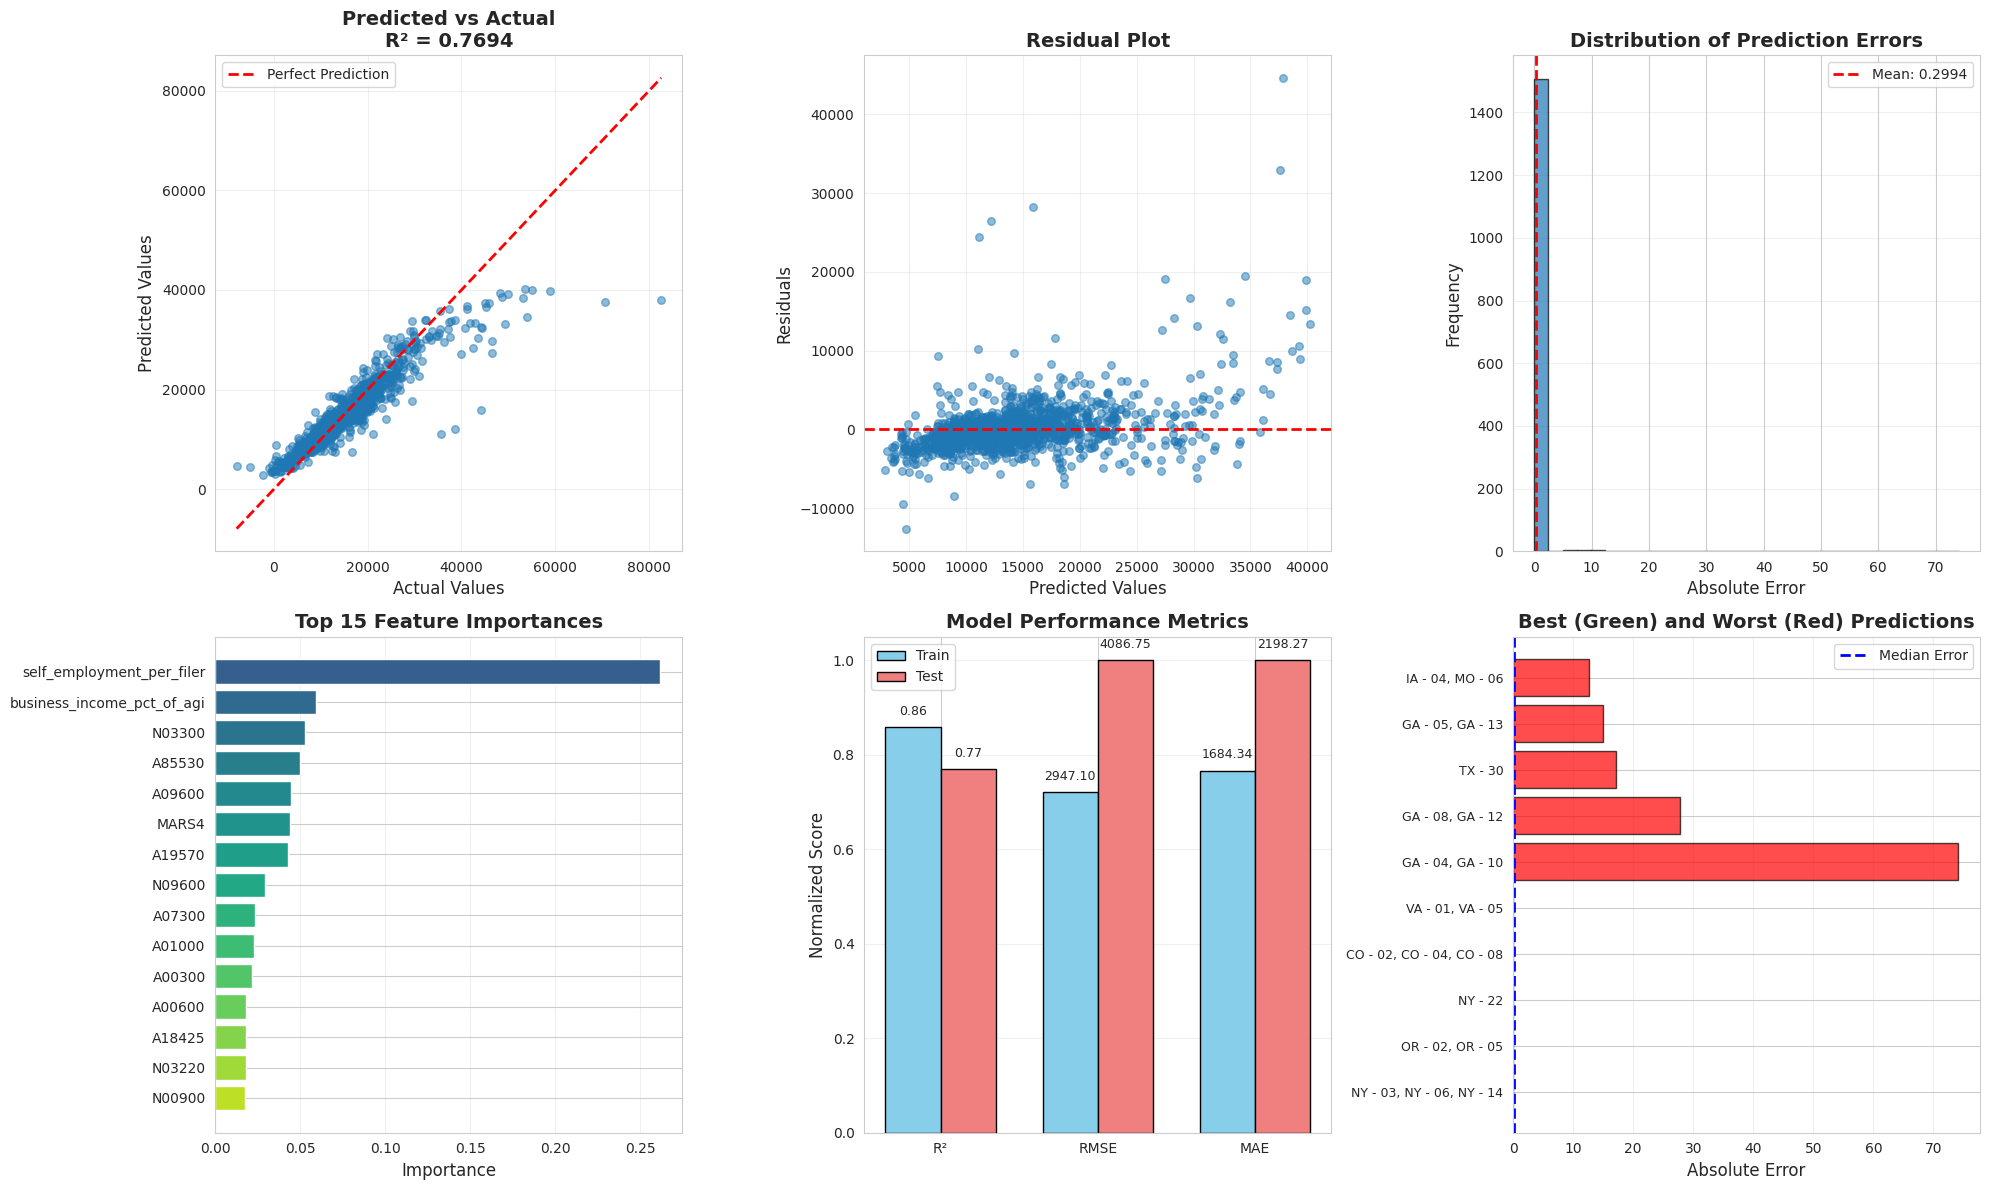

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

class MLModel:

  def __init__(self, data_file = 'irs_sba_merged_2022.csv'):
    print("-"*70)
    print("Loading Merged Data")
    print("-"*70)

    self.df = pd.read_csv(data_file)
    print(f"Loaded {len(self.df)} districts with {len(self.df.columns)} columns")
    print(f"Columns loaded by MLModel: {self.df.columns.tolist()[:10]}...")

    self.model = None
    self.scaler = None
    self.feature_cols = None
    self.target_cols = None
    self.X_train = None
    self.X_test = None
    self.y_train = None
    self.y_test = None

  def prep_data(self, target_column, feature_columns=None, drop_na=True):
    print("\n" + "-•-"*40)
    print("Preparing data...")
    print("-•-"*40)

    if target_column not in self.df.columns:
      print(f"Target column '{target_column}' not found!")
      available_derived_cols = [col for col in self.df.columns if 'business' in col.lower() or 'income' in col.lower() or 'filer' in col.lower() or 'agi' in col.lower() or 'pct' in col.lower() or 'tax' in col.lower()]
      print(f"Available derived columns: {available_derived_cols}")
      return False

    self.target_col = target_column

    if drop_na:
      df_clean = self.df[self.df[target_column].notna()].copy()
      print(f"Removed {len(self.df) - len(df_clean)} rows with missing target values")
    else:
      df_clean = self.df.copy()

    if df_clean.empty:
        print("✗ Cleaned DataFrame is empty after dropping NaNs. Cannot proceed with data prep.")
        return False

    if feature_columns is None:
      exclude_cols = [target_column, 'congressional_district', 'state', 'zipcode', 'num_zipcodes', 'data_source']
      numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
      feature_columns = [col for col in numeric_cols if col not in exclude_cols]
      feature_columns = [col for col in feature_columns if 'percentile' not in col.lower()]

      print(f"\nAuto-selected {len(feature_columns)} features")

    if 'congressional_district' not in self.df.columns:
        print("✗ 'congressional_district' column not found in the DataFrame. Cannot proceed.")
        return False

    self.feature_cols = feature_columns

    X = df_clean[feature_columns].copy()
    y = df_clean[target_column].copy()

    if X.empty or y.empty:
        print("✗ X or y are empty after feature/target selection. Cannot proceed.")
        return False

    X = X.fillna(X.median())

    variance = X.var()
    zero_var_cols = variance[variance == 0].index.tolist()
    if zero_var_cols:
        print(f"⚠ Removing {len(zero_var_cols)} zero-variance columns")
        X = X.drop(columns=zero_var_cols)
        self.feature_cols = [col for col in self.feature_cols if col not in zero_var_cols]

    if len(X.columns) > 1:
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]
        if high_corr_cols:
            print(f"⚠ Removing {len(high_corr_cols)} highly correlated features")
            X = X.drop(columns=high_corr_cols)
            self.feature_cols = [col for col in self.feature_cols if col not in high_corr_cols]

    print(f"\nDataset size: {len(X)} districts")
    print(f"Features: {len(self.feature_cols)}")
    print(f"Target: {target_column}")
    print(f"Target range: [{y.min():.2f}, {y.max():.2f}]")
    print(f"Target mean: {y.mean():.2f}")

    self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"\nTrain set: {len(self.X_train)} districts (80%)")
    print(f"Test set: {len(self.X_test)} districts (20%)")
    return True

  def train_model(self, n_estimators=100, max_depth=8, min_samples_split=20, min_samples_leaf=10, max_features='sqrt'):
    print("\n" + "-•-"*40)
    print("Training Random Forest Model (Anti-Overfitting Config)")
    print("-•-"*40)

    if self.X_train is None or self.X_train.empty or self.y_train is None or self.y_train.empty:
        print("✗ Training data is empty or not prepared. Skipping training.")
        return {
            'train_r2': np.nan, 'test_r2': np.nan,
            'train_rmse': np.nan, 'test_rmse': np.nan,
            'train_mae': np.nan, 'test_mae': np.nan,
            'train_predictions': np.array([]), 'test_predictions': np.array([])
        }

    self.scaler = StandardScaler()
    X_train_scaled = self.scaler.fit_transform(self.X_train)
    X_test_scaled = self.scaler.transform(self.X_test)

    print(f"\nTraining with {n_estimators} trees")
    print(f"  max_depth={max_depth}, min_samples_split={min_samples_split}")
    print(f"  min_samples_leaf={min_samples_leaf}, max_features='{max_features}'")

    self.model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,
        bootstrap=True
    )

    self.model.fit(X_train_scaled, self.y_train)

    print("✓ Training complete!")

    y_train_pred = self.model.predict(X_train_scaled)
    y_test_pred = self.model.predict(X_test_scaled)

    print("\n" + "-•-"*40)
    print("MODEL PERFORMANCE")
    print("-•-"*40)

    train_r2 = r2_score(self.y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(self.y_train, y_train_pred))
    train_mae = mean_absolute_error(self.y_train, y_train_pred)

    print("\nTraining Set:")
    print(f"  R² Score: {train_r2:.4f}")
    print(f"  RMSE: {train_rmse:.2f}")
    print(f"  MAE: {train_mae:.2f}")

    test_r2 = r2_score(self.y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(self.y_test, y_test_pred))
    test_mae = mean_absolute_error(self.y_test, y_test_pred)

    print("\nTest Set:")
    print(f"  R² Score: {test_r2:.4f}")
    print(f"  RMSE: {test_rmse:.2f}")
    print(f"  MAE: {test_mae:.2f}")

    r2_diff = train_r2 - test_r2
    if r2_diff > 0.15:
        print(f"\n⚠⚠ SEVERE OVERFITTING (Δ R² = {r2_diff:.4f})")
    elif r2_diff > 0.1:
        print(f"\n⚠ Moderate Overfitting (Δ R² = {r2_diff:.4f})")
    else:
        print(f"\n✓ Good generalization (Δ R² = {r2_diff:.4f})")

    return{
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_predictions': y_train_pred,
        'test_predictions': y_test_pred,
        'r2_diff': r2_diff
    }

  def feature_importance(self, top_n=20):
    if self.model is None:
      print("No model trained yet")
      return None

    print("\n" + "-•-"*40)
    print(f"TOP {top_n} MOST IMPORTANT FEATURES")
    print("-•-"*40)

    importance_df = pd.DataFrame({
        'feature': self.feature_cols,
        'importance': self.model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(importance_df.head(top_n).to_string(index=False))

    return importance_df

  def predict_districts(self):
    if self.model is None:
      print("No model trained yet")
      return None

    print("\n" + "-•-"*40)
    print("PREDICTING ALL DISTRICTS")
    print("-•-"*40)

    X_all = self.df[self.feature_cols].copy()
    X_all = X_all.fillna(self.df[self.feature_cols].median())
    X_all_scaled = self.scaler.transform(X_all)

    predictions = self.model.predict(X_all_scaled)

    result_df = self.df[['congressional_district', 'state']].copy()
    if self.target_col in self.df.columns:
        result_df[f'{self.target_col}_actual'] = self.df[self.target_col]
    else:
        result_df[f'{self.target_col}_actual'] = np.nan

    result_df[f'{self.target_col}_predicted'] = predictions
    result_df['prediction_error'] = (result_df[f'{self.target_col}_actual'] - result_df[f'{self.target_col}_predicted'])/(result_df[f'{self.target_col}_actual'])
    result_df['absolute_error'] = result_df['prediction_error'].abs()

    print(f"Generated predictions for {len(result_df)} districts")

    valid_predictions = result_df[result_df[f'{self.target_col}_actual'].notna()]
    if not valid_predictions.empty:
        print("\nBest Predictions (lowest error):")
        print(valid_predictions.nsmallest(5, 'absolute_error')[
            ['congressional_district', f'{self.target_col}_actual',
              f'{self.target_col}_predicted', 'prediction_error']
        ].to_string(index=False))

        print("\nWorst Predictions (highest error):")
        print(valid_predictions.nlargest(5, 'absolute_error')[
          ['congressional_district', f'{self.target_col}_actual',
            f'{self.target_col}_predicted', 'prediction_error']
        ].to_string(index=False))
    else:
        print("No valid predictions to display (no actual target values).")

    return result_df

  def visualize_results(self, results_dict, predictions_df, importance_df):
    """
    Create comprehensive visualizations of model performance.
    """
    fig = plt.figure(figsize=(20, 12))

    # 1. Predicted vs Actual (Top Left)
    ax1 = plt.subplot(2, 3, 1)
    valid_pred = predictions_df[predictions_df[f'{self.target_col}_actual'].notna()]
    ax1.scatter(valid_pred[f'{self.target_col}_actual'],
                valid_pred[f'{self.target_col}_predicted'],
                alpha=0.5, s=30)

    # Perfect prediction line
    min_val = min(valid_pred[f'{self.target_col}_actual'].min(),
                  valid_pred[f'{self.target_col}_predicted'].min())
    max_val = max(valid_pred[f'{self.target_col}_actual'].max(),
                  valid_pred[f'{self.target_col}_predicted'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

    ax1.set_xlabel('Actual Values', fontsize=12)
    ax1.set_ylabel('Predicted Values', fontsize=12)
    ax1.set_title(f'Predicted vs Actual\nR² = {results_dict["test_r2"]:.4f}', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Residual Plot (Top Middle)
    ax2 = plt.subplot(2, 3, 2)
    residuals = valid_pred[f'{self.target_col}_actual'] - valid_pred[f'{self.target_col}_predicted']
    ax2.scatter(valid_pred[f'{self.target_col}_predicted'], residuals, alpha=0.5, s=30)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted Values', fontsize=12)
    ax2.set_ylabel('Residuals', fontsize=12)
    ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # 3. Error Distribution (Top Right)
    ax3 = plt.subplot(2, 3, 3)
    ax3.hist(valid_pred['absolute_error'], bins=30, edgecolor='black', alpha=0.7)
    ax3.set_xlabel('Absolute Error', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    ax3.axvline(valid_pred['absolute_error'].mean(), color='r', linestyle='--',
                lw=2, label=f'Mean: {valid_pred["absolute_error"].mean():.4f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # 4. Feature Importance (Bottom Left)
    ax4 = plt.subplot(2, 3, 4)
    top_15 = importance_df.head(15)
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15)))
    ax4.barh(range(len(top_15)), top_15['importance'], color=colors)
    ax4.set_yticks(range(len(top_15)))
    ax4.set_yticklabels(top_15['feature'], fontsize=10)
    ax4.set_xlabel('Importance', fontsize=12)
    ax4.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    ax4.invert_yaxis()
    ax4.grid(True, alpha=0.3, axis='x')

    # 5. Performance Metrics Comparison (Bottom Middle)
    ax5 = plt.subplot(2, 3, 5)
    metrics = ['R²', 'RMSE', 'MAE']
    train_vals = [results_dict['train_r2'], results_dict['train_rmse'], results_dict['train_mae']]
    test_vals = [results_dict['test_r2'], results_dict['test_rmse'], results_dict['test_mae']]

    x = np.arange(len(metrics))
    width = 0.35

    # Normalize RMSE and MAE to 0-1 scale for visualization
    max_rmse = max(results_dict['train_rmse'], results_dict['test_rmse'])
    max_mae = max(results_dict['train_mae'], results_dict['test_mae'])
    train_vals_norm = [train_vals[0], train_vals[1]/max_rmse, train_vals[2]/max_mae]
    test_vals_norm = [test_vals[0], test_vals[1]/max_rmse, test_vals[2]/max_mae]

    ax5.bar(x - width/2, train_vals_norm, width, label='Train', color='skyblue', edgecolor='black')
    ax5.bar(x + width/2, test_vals_norm, width, label='Test', color='lightcoral', edgecolor='black')

    ax5.set_ylabel('Normalized Score', fontsize=12)
    ax5.set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(metrics)
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')

    # Add actual values as text
    for i, (tv, test_v) in enumerate(zip(train_vals, test_vals)):
        ax5.text(i - width/2, train_vals_norm[i] + 0.02, f'{tv:.2f}',
                ha='center', va='bottom', fontsize=9)
        ax5.text(i + width/2, test_vals_norm[i] + 0.02, f'{test_v:.2f}',
                ha='center', va='bottom', fontsize=9)

    # 6. Top/Bottom Districts by Error (Bottom Right)
    ax6 = plt.subplot(2, 3, 6)
    top_5 = valid_pred.nsmallest(5, 'absolute_error')
    bottom_5 = valid_pred.nlargest(5, 'absolute_error')

    combined = pd.concat([top_5, bottom_5])
    colors_districts = ['green']*5 + ['red']*5

    y_pos = range(len(combined))
    ax6.barh(y_pos, combined['absolute_error'], color=colors_districts, alpha=0.7, edgecolor='black')
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(combined['congressional_district'], fontsize=9)
    ax6.set_xlabel('Absolute Error', fontsize=12)
    ax6.set_title('Best (Green) and Worst (Red) Predictions', fontsize=14, fontweight='bold')
    ax6.axvline(valid_pred['absolute_error'].median(), color='blue', linestyle='--',
                lw=2, label='Median Error')
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig(f'model_visualization_{self.target_col}.png', dpi=300, bbox_inches='tight')
    print(f"\n✓ Visualization saved: model_visualization_{self.target_col}.png")
    plt.show()

    return fig

  def save_results(self, predictions_file='ml_predictions.csv', importance_file='feature_importance.csv'):
    predictions = self.predict_districts()
    if predictions is not None:
      predictions.to_csv(predictions_file, index=False)
      print(f"\nPredictions saved to: {predictions_file}")

    importance = self.feature_importance(top_n=50)
    if importance is not None:
      importance.to_csv(importance_file, index=False)
      print(f"\nFeature importance saved to: {importance_file}")

    return predictions, importance


# ==================================================================
# USAGE WITH VISUALIZATIONS
# ==================================================================

ml_model = MLModel('irs_sba_merged_2022.csv')
if ml_model.prep_data(target_column='business_income_per_filer'):
    results = ml_model.train_model(n_estimators=150, max_depth=8, min_samples_split=20, min_samples_leaf=10)
    predictions, importance = ml_model.save_results(
        predictions_file='business_income_predictions.csv',
        importance_file='business_income_importance.csv'
    )

    # CREATE VISUALIZATION
    ml_model.visualize_results(results, predictions, importance)

----------------------------------------------------------------------
Loading Merged Data for Multi-Model Comparison
----------------------------------------------------------------------
Loaded 1525 districts with 180 columns

PREPARING DATA FOR TARGET: business_income_per_filer
Removed 2 rows with missing target
⚠ Removing 1 zero-variance columns

✓ Dataset: 1523 districts × 169 features
✓ Target range: [-7861.48, 82533.96]
✓ Train: 1218 | Test: 305

INITIALIZING MODELS
✓ Initialized 4 models:
  • Random Forest
  • Gradient Boosting
  • Decision Tree
  • K-Nearest Neighbors

TRAINING ALL MODELS

Training Random Forest... ✓ (Test R²: 0.7646)
Training Gradient Boosting... ✓ (Test R²: 0.8878)
Training Decision Tree... ✓ (Test R²: 0.8089)
Training K-Nearest Neighbors... ✓ (Test R²: 0.8290)

MODEL COMPARISON RESULTS

              model  train_r2  test_r2  r2_diff  train_rmse   test_rmse    test_mae
  Gradient Boosting  0.991650 0.887760 0.103890  715.991245 2851.426508 1356.412532
K-Nea

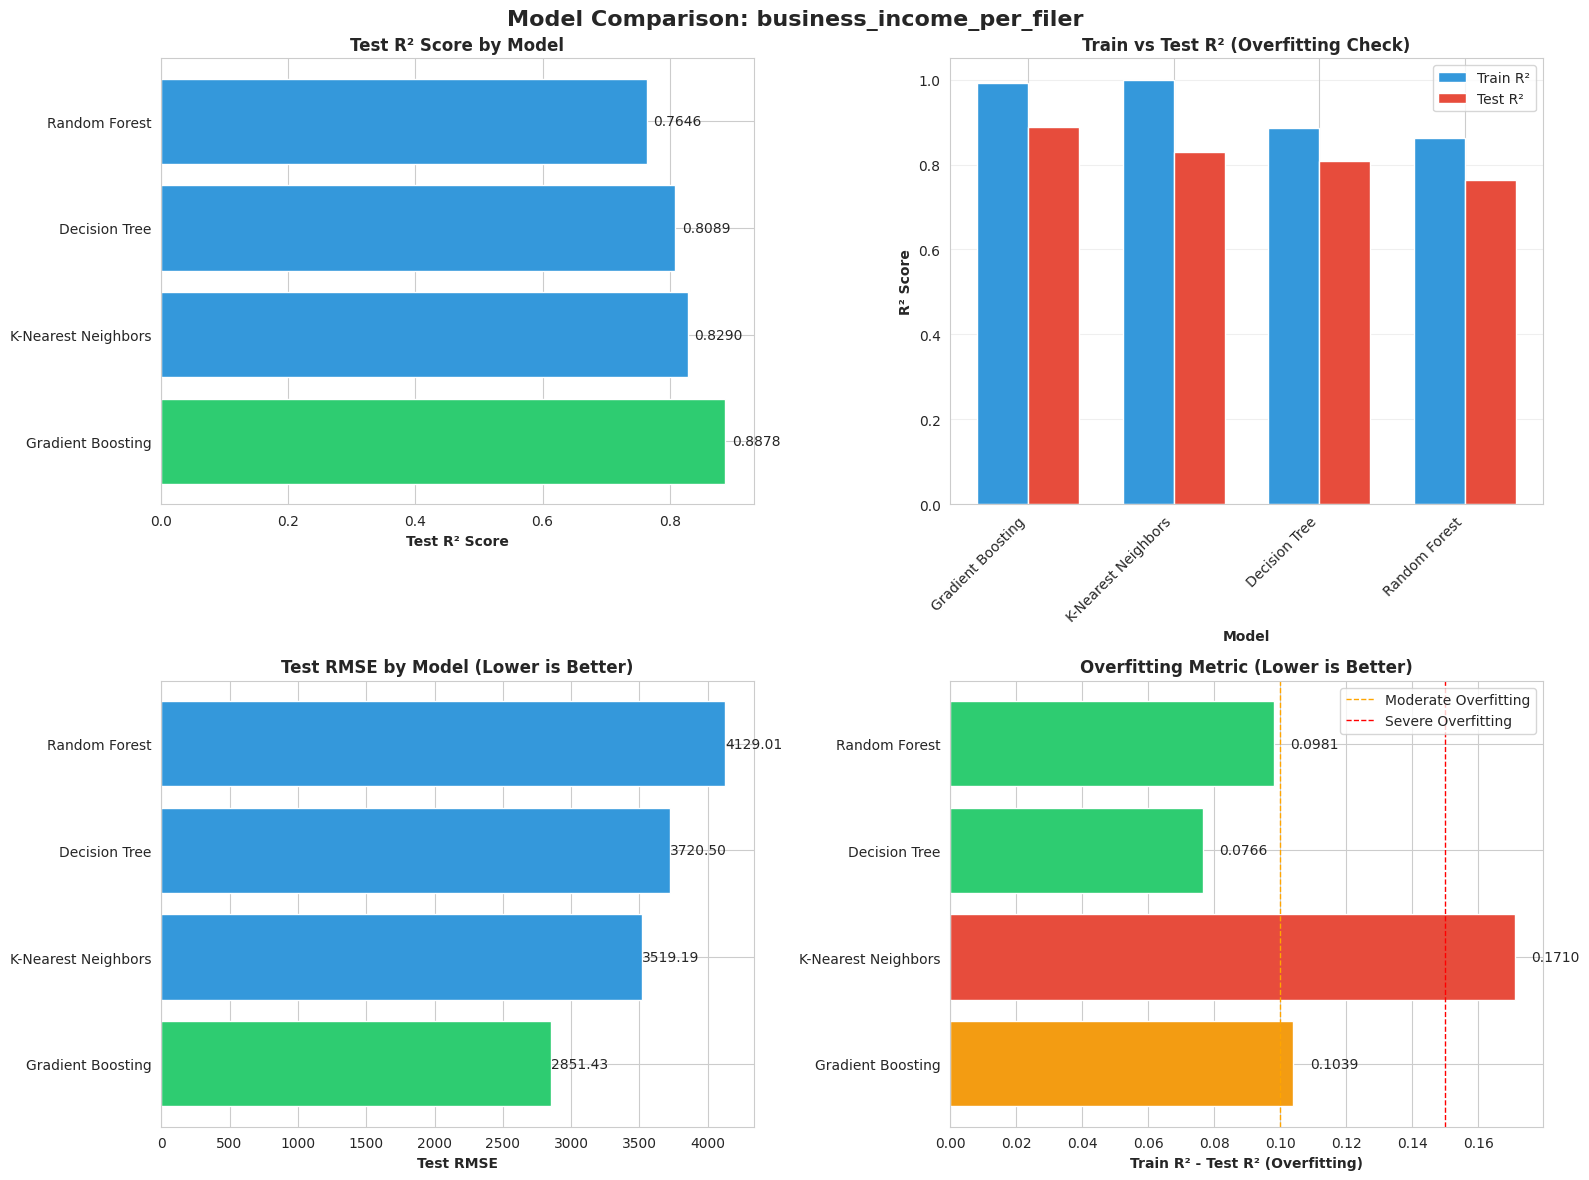

✓ Results saved: business_income_multi_model_results.csv


TESTING MULTIPLE TARGETS

TARGET: pct_returns_with_business
----------------------------------------------------------------------
Loading Merged Data for Multi-Model Comparison
----------------------------------------------------------------------
Loaded 1525 districts with 180 columns

PREPARING DATA FOR TARGET: pct_returns_with_business
Removed 2 rows with missing target
⚠ Removing 1 zero-variance columns

✓ Dataset: 1523 districts × 169 features
✓ Target range: [6.06, 48.17]
✓ Train: 1218 | Test: 305

INITIALIZING MODELS
✓ Initialized 4 models:
  • Random Forest
  • Gradient Boosting
  • Decision Tree
  • K-Nearest Neighbors

TRAINING ALL MODELS

Training Random Forest... ✓ (Test R²: 0.5808)
Training Gradient Boosting... ✓ (Test R²: 0.7749)
Training Decision Tree... ✓ (Test R²: 0.4190)
Training K-Nearest Neighbors... ✓ (Test R²: 0.6249)

MODEL COMPARISON RESULTS

              model  train_r2  test_r2  r2_diff  train_rmse  

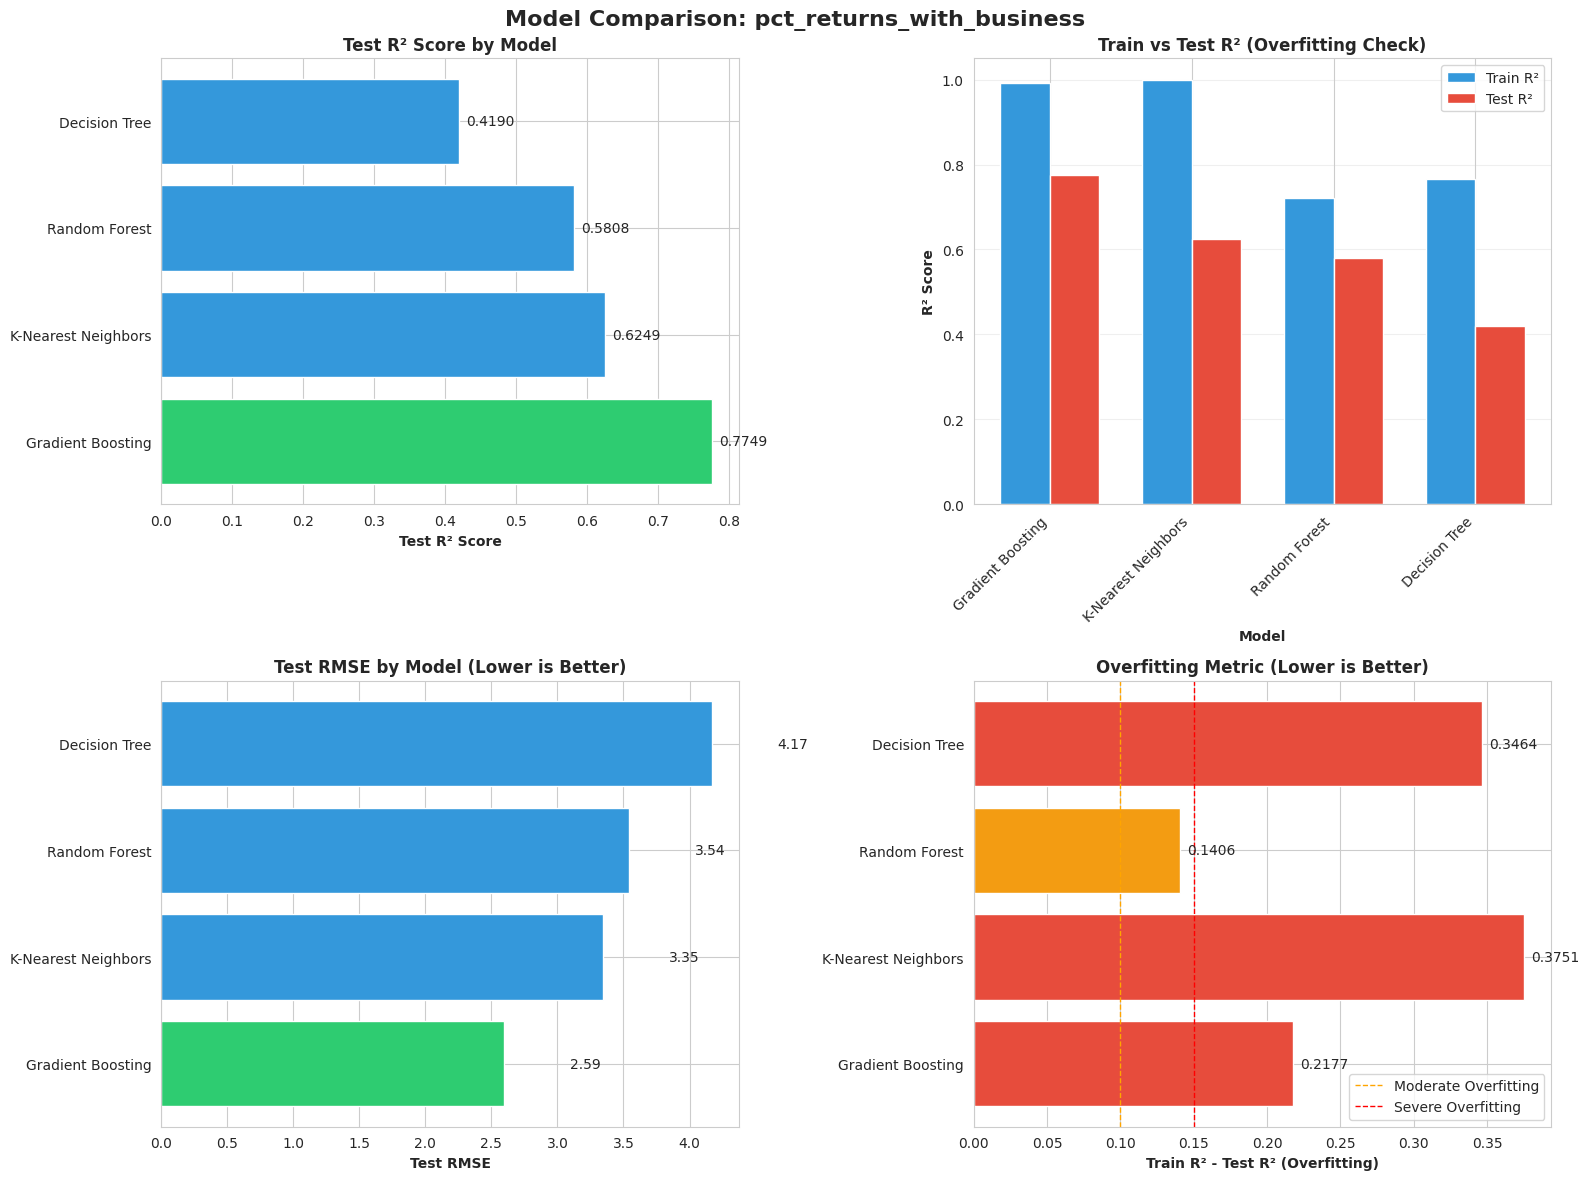

✓ Results saved: pct_returns_with_business_multi_model_results.csv

TARGET: business_income_pct_of_agi
----------------------------------------------------------------------
Loading Merged Data for Multi-Model Comparison
----------------------------------------------------------------------
Loaded 1525 districts with 180 columns

PREPARING DATA FOR TARGET: business_income_pct_of_agi
Removed 2 rows with missing target
⚠ Removing 1 zero-variance columns

✓ Dataset: 1523 districts × 169 features
✓ Target range: [-6.22, 21.02]
✓ Train: 1218 | Test: 305

INITIALIZING MODELS
✓ Initialized 4 models:
  • Random Forest
  • Gradient Boosting
  • Decision Tree
  • K-Nearest Neighbors

TRAINING ALL MODELS

Training Random Forest... ✓ (Test R²: 0.2319)
Training Gradient Boosting... ✓ (Test R²: 0.7178)
Training Decision Tree... ✓ (Test R²: 0.3412)
Training K-Nearest Neighbors... ✓ (Test R²: 0.5202)

MODEL COMPARISON RESULTS

              model  train_r2  test_r2  r2_diff   train_rmse  test_rmse  te

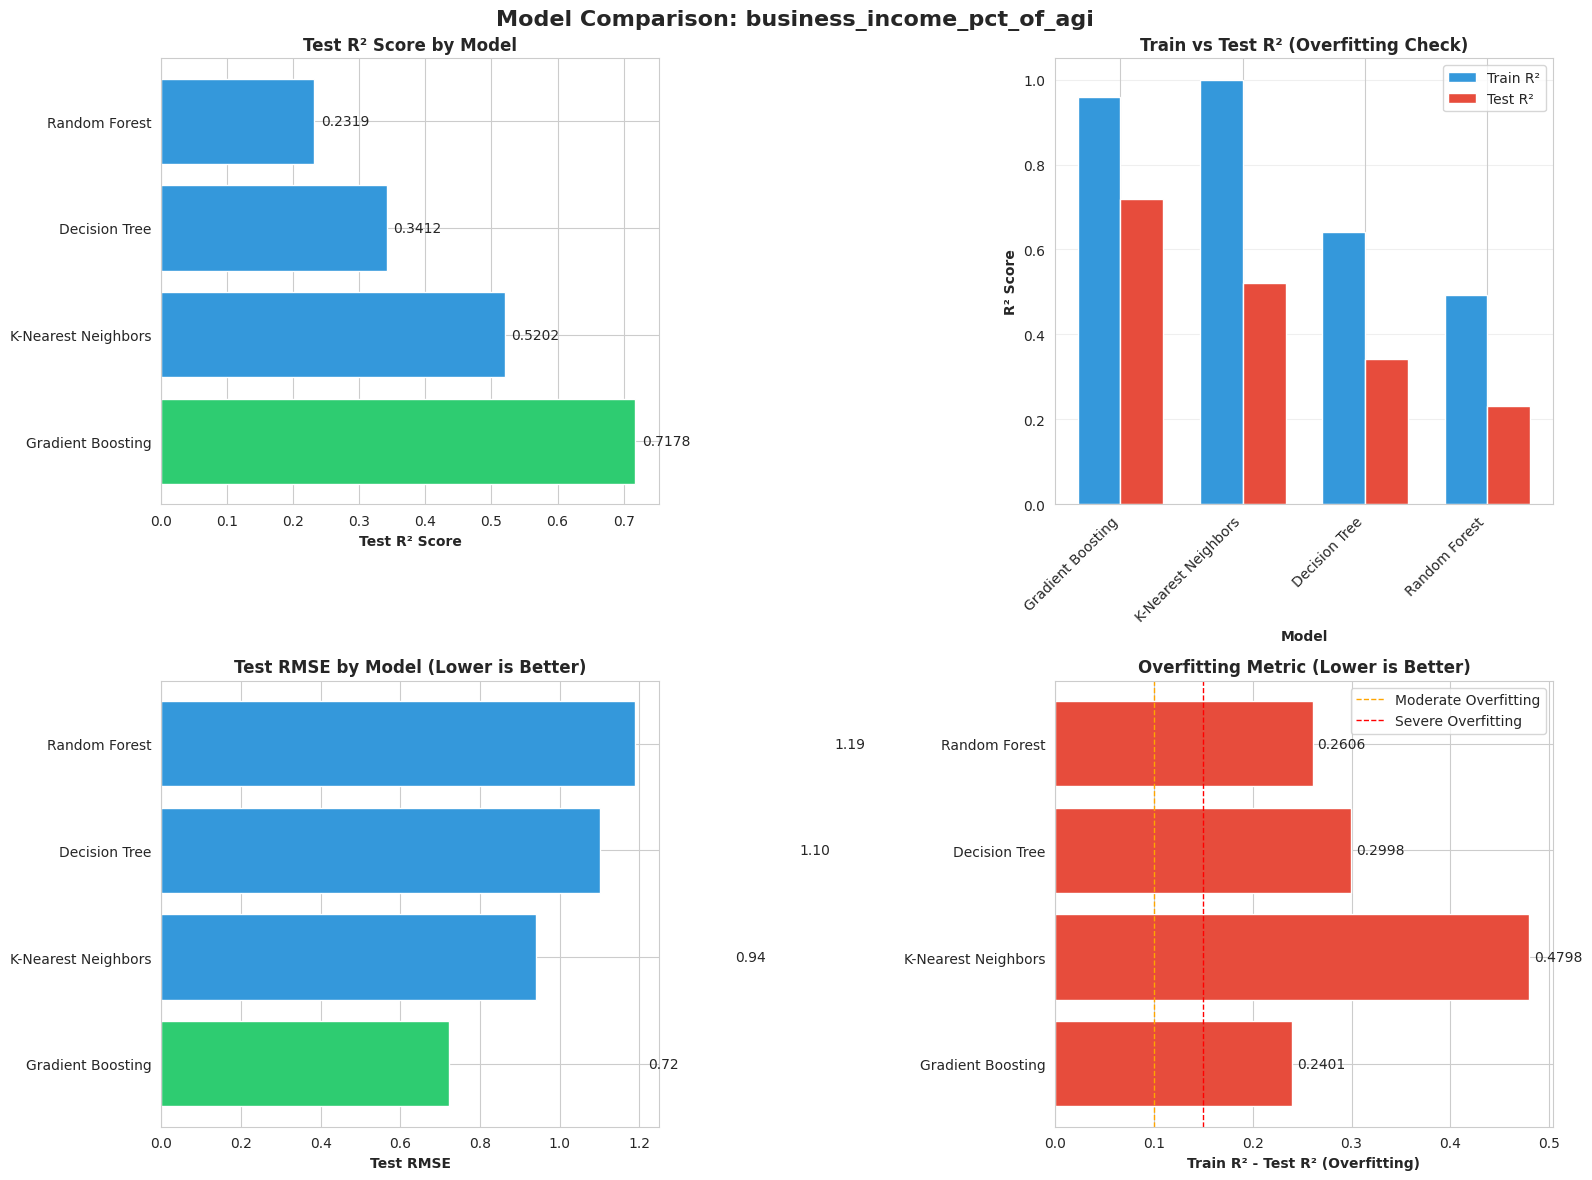

✓ Results saved: business_income_pct_of_agi_multi_model_results.csv

TARGET: total_business_income_thousands
----------------------------------------------------------------------
Loading Merged Data for Multi-Model Comparison
----------------------------------------------------------------------
Loaded 1525 districts with 180 columns

PREPARING DATA FOR TARGET: total_business_income_thousands
✗ Target column 'total_business_income_thousands' not found!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class MultiModelMLComparison:

    def __init__(self, data_file='irs_sba_merged_2022.csv'):
        print("-"*70)
        print("Loading Merged Data for Multi-Model Comparison")
        print("-"*70)

        self.df = pd.read_csv(data_file)
        print(f"Loaded {len(self.df)} districts with {len(self.df.columns)} columns")

        self.models = {}
        self.results = []
        self.best_model = None
        self.best_model_name = None
        self.scaler = StandardScaler()

    def prep_data(self, target_column, drop_na=True):
        print(f"\n{'='*70}")
        print(f"PREPARING DATA FOR TARGET: {target_column}")
        print(f"{'='*70}")

        if target_column not in self.df.columns:
            print(f"✗ Target column '{target_column}' not found!")
            return False

        self.target_col = target_column

        # clean data
        if drop_na:
            df_clean = self.df[self.df[target_column].notna()].copy()
            print(f"Removed {len(self.df) - len(df_clean)} rows with missing target")
        else:
            df_clean = self.df.copy()

        if df_clean.empty:
            print("✗ No data after cleaning")
            return False

        # selecting features
        exclude_cols = [target_column, 'congressional_district', 'state', 'zipcode', 'num_zipcodes', 'data_source']
        numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
        feature_columns = [col for col in numeric_cols if col not in exclude_cols and 'percentile' not in col.lower()]

        self.feature_cols = feature_columns

        X = df_clean[feature_columns].copy()
        y = df_clean[target_column].copy()

        X = X.fillna(X.median())

        # remove zero variance and highly correlated features
        variance = X.var()
        zero_var_cols = variance[variance == 0].index.tolist()
        if zero_var_cols:
            print(f"⚠ Removing {len(zero_var_cols)} zero-variance columns")
            X = X.drop(columns=zero_var_cols)
            self.feature_cols = [col for col in self.feature_cols if col not in zero_var_cols]

        print(f"\n✓ Dataset: {len(X)} districts × {len(self.feature_cols)} features")
        print(f"✓ Target range: [{y.min():.2f}, {y.max():.2f}]")

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Scale features
        self.X_train_scaled = self.scaler.fit_transform(self.X_train)
        self.X_test_scaled = self.scaler.transform(self.X_test)

        print(f"✓ Train: {len(self.X_train)} | Test: {len(self.X_test)}")

        return True

    def initialize_models(self):
        print(f"\n{'='*70}")
        print("INITIALIZING MODELS")
        print(f"{'='*70}")

        self.models = {
            # Tree-based models
            'Random Forest': RandomForestRegressor(
                n_estimators=150, max_depth=8, min_samples_split=20,
                min_samples_leaf=10, max_features='sqrt', random_state=42, n_jobs=-1
            ),
            'Gradient Boosting': GradientBoostingRegressor(
                n_estimators=150, max_depth=5, learning_rate=0.1,
                min_samples_split=20, min_samples_leaf=10, random_state=42
            ),
            'Decision Tree': DecisionTreeRegressor(
                max_depth=8, min_samples_split=20, min_samples_leaf=10, random_state=42
            ),

            'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=10, weights='distance')
        }

        print(f"✓ Initialized {len(self.models)} models:")
        for name in self.models.keys():
            print(f"  • {name}")

    def train_all_models(self):
        print(f"\n{'='*70}")
        print("TRAINING ALL MODELS")
        print(f"{'='*70}\n")

        self.results = []

        for name, model in self.models.items():
            print(f"Training {name}...", end=" ")

            try:
                # Train model
                model.fit(self.X_train_scaled, self.y_train)

                # Make predictions
                y_train_pred = model.predict(self.X_train_scaled)
                y_test_pred = model.predict(self.X_test_scaled)

                # Calculate metrics
                train_r2 = r2_score(self.y_train, y_train_pred)
                test_r2 = r2_score(self.y_test, y_test_pred)
                train_rmse = np.sqrt(mean_squared_error(self.y_train, y_train_pred))
                test_rmse = np.sqrt(mean_squared_error(self.y_test, y_test_pred))
                test_mae = mean_absolute_error(self.y_test, y_test_pred)
                r2_diff = train_r2 - test_r2

                # Store results
                self.results.append({
                    'model': name,
                    'train_r2': train_r2,
                    'test_r2': test_r2,
                    'r2_diff': r2_diff,
                    'train_rmse': train_rmse,
                    'test_rmse': test_rmse,
                    'test_mae': test_mae,
                    'model_object': model
                })

                print(f"✓ (Test R²: {test_r2:.4f})")

            except Exception as e:
                print(f"✗ Failed: {e}")

        # Convert to DataFrame and sort
        self.results_df = pd.DataFrame(self.results).sort_values('test_r2', ascending=False)

        # Identify best model
        if len(self.results_df) > 0:
            self.best_model_name = self.results_df.iloc[0]['model']
            self.best_model = self.results_df.iloc[0]['model_object']

        return self.results_df

    def display_results(self):
        """Display comparison results."""
        print(f"\n{'='*70}")
        print("MODEL COMPARISON RESULTS")
        print(f"{'='*70}\n")

        display_df = self.results_df.drop(columns=['model_object'])
        print(display_df.to_string(index=False))

        print(f"\n{'='*70}")
        print(f"🏆 BEST MODEL: {self.best_model_name}")
        print(f"{'='*70}")
        best = self.results_df.iloc[0]
        print(f"Test R²: {best['test_r2']:.4f}")
        print(f"Test RMSE: {best['test_rmse']:.2f}")
        print(f"Test MAE: {best['test_mae']:.2f}")
        print(f"Overfitting (Δ R²): {best['r2_diff']:.4f}")

    def visualize_comparison(self, save_path='model_comparison.png'):
        """Create visualization comparing all models."""
        print(f"\n{'='*70}")
        print("CREATING VISUALIZATIONS")
        print(f"{'='*70}")

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Model Comparison: {self.target_col}', fontsize=16, fontweight='bold')

        # 1. Test R² Score comparison
        ax1 = axes[0, 0]
        models = self.results_df['model']
        test_r2 = self.results_df['test_r2']
        colors = ['#2ecc71' if r2 == test_r2.max() else '#3498db' for r2 in test_r2]
        ax1.barh(models, test_r2, color=colors)
        ax1.set_xlabel('Test R² Score', fontweight='bold')
        ax1.set_title('Test R² Score by Model', fontweight='bold')
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        for i, v in enumerate(test_r2):
            ax1.text(v + 0.01, i, f'{v:.4f}', va='center')

        # 2. Train vs Test R² (Overfitting Check)
        ax2 = axes[0, 1]
        x = np.arange(len(models))
        width = 0.35
        ax2.bar(x - width/2, self.results_df['train_r2'], width, label='Train R²', color='#3498db')
        ax2.bar(x + width/2, self.results_df['test_r2'], width, label='Test R²', color='#e74c3c')
        ax2.set_xlabel('Model', fontweight='bold')
        ax2.set_ylabel('R² Score', fontweight='bold')
        ax2.set_title('Train vs Test R² (Overfitting Check)', fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(models, rotation=45, ha='right')
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)

        # 3. Test RMSE comparison
        ax3 = axes[1, 0]
        test_rmse = self.results_df['test_rmse']
        colors = ['#2ecc71' if rmse == test_rmse.min() else '#3498db' for rmse in test_rmse]
        ax3.barh(models, test_rmse, color=colors)
        ax3.set_xlabel('Test RMSE', fontweight='bold')
        ax3.set_title('Test RMSE by Model (Lower is Better)', fontweight='bold')
        for i, v in enumerate(test_rmse):
            ax3.text(v + 0.5, i, f'{v:.2f}', va='center')

        # 4. Overfitting metric (R² difference)
        ax4 = axes[1, 1]
        r2_diff = self.results_df['r2_diff']
        colors = ['#e74c3c' if diff > 0.15 else '#f39c12' if diff > 0.1 else '#2ecc71' for diff in r2_diff]
        ax4.barh(models, r2_diff, color=colors)
        ax4.set_xlabel('Train R² - Test R² (Overfitting)', fontweight='bold')
        ax4.set_title('Overfitting Metric (Lower is Better)', fontweight='bold')
        ax4.axvline(x=0.1, color='orange', linestyle='--', linewidth=1, label='Moderate Overfitting')
        ax4.axvline(x=0.15, color='red', linestyle='--', linewidth=1, label='Severe Overfitting')
        ax4.legend()
        for i, v in enumerate(r2_diff):
            ax4.text(v + 0.005, i, f'{v:.4f}', va='center')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Visualization saved: {save_path}")
        plt.show()

    def save_results(self, results_file='multi_model_results.csv'):
        """Save comparison results to CSV."""
        output_df = self.results_df.drop(columns=['model_object'])
        output_df.to_csv(results_file, index=False)
        print(f"✓ Results saved: {results_file}")


# ==================== USAGE ====================

# Initialize comparison
comparison = MultiModelMLComparison('irs_sba_merged_2022.csv')

# Prepare data for target
if comparison.prep_data(target_column='business_income_per_filer'):

    # Initialize all models
    comparison.initialize_models()

    # Train all models
    comparison.train_all_models()

    # Display results
    comparison.display_results()

    # Create visualization
    comparison.visualize_comparison(save_path='business_income_model_comparison.png')

    # Save results
    comparison.save_results(results_file='business_income_multi_model_results.csv')


# Test on other targets
print("\n\n" + "="*70)
print("TESTING MULTIPLE TARGETS")
print("="*70)

targets_to_test = [
    'pct_returns_with_business',
    'business_income_pct_of_agi',
    'total_business_income_thousands'
]

for target in targets_to_test:
    print(f"\n{'='*70}")
    print(f"TARGET: {target}")
    print(f"{'='*70}")

    comp = MultiModelMLComparison('irs_sba_merged_2022.csv')
    if comp.prep_data(target_column=target):
        comp.initialize_models()
        comp.train_all_models()
        comp.display_results()
        comp.visualize_comparison(save_path=f'{target}_model_comparison.png')
        comp.save_results(results_file=f'{target}_multi_model_results.csv')

## How to Connect to GitHub and Commit Changes in Google Colab

Google Colab allows you to save copies of your notebooks directly to GitHub repositories. Here's a general guide:

### Step 1: Save a Copy to GitHub

1.  Go to `File` in the Colab menu bar.
2.  Select `Save a copy to GitHub...`.
3.  A dialog box will appear. You may need to authorize Colab to access your GitHub account if you haven't done so before.
4.  Choose the GitHub **repository** where you want to save the notebook.
5.  (Optional) Provide a **commit message** that describes the changes you are saving.
6.  Click `OK` or `Save`.

Colab will then save a copy of your current notebook to the specified GitHub repository.

### Step 2: Open a Notebook from GitHub (for future work)

To continue working on a notebook that is already on GitHub:

1.  Go to `File` in the Colab menu bar.
2.  Select `Open notebook`.
3.  In the `Open notebook` dialog, select the `GitHub` tab.
4.  Search for your GitHub repository and select the desired notebook.
5.  Click `Open`.

This will open the notebook directly from GitHub.

### Step 3: Pushing Subsequent Changes to GitHub

Once you've initially saved a copy to GitHub and opened it from GitHub, Colab will keep track of the source. For subsequent changes:

1.  Make your desired changes in the Colab notebook.
2.  Go to `File` in the Colab menu bar.
3.  Select `Save a copy to GitHub...` again.
4.  The dialog box should pre-populate with the repository and file path. You can add a new commit message.
5.  Click `OK` or `Save`.

Colab will push your changes as a new commit to the same GitHub repository and file.

### Important Notes:

*   **Authentication**: Ensure your Colab is authorized with your GitHub account. You might be prompted to re-authenticate occasionally.
*   **Branches**: Colab typically saves to the default branch (e.g., `main` or `master`). If you need to work on a specific branch, you might have to manage that directly on GitHub or use Git commands within Colab (which is more advanced).
*   **Version Control**: This method creates new commits on GitHub, preserving the history of your changes.

### Authorizing Colab with GitHub

1.  **Initiate Save to GitHub**: In your Colab notebook, go to `File` > `Save a copy to GitHub...`.

2.  **Redirect to GitHub**: If you're not already authorized, Colab will redirect you to GitHub. You might see a GitHub page asking for your credentials (username and password).

3.  **Grant Permissions**: After logging in, GitHub will ask you to authorize Google Colaboratory to access your repositories. You'll typically need to grant permissions for Colab to:
    *   Read your user data.
    *   Access your repositories (often read/write access to allow saving notebooks).

4.  **Confirm Authorization**: Once you grant the necessary permissions on GitHub, you'll be redirected back to Colab. The `Save a copy to GitHub` dialog should now appear, allowing you to select your repository and commit your notebook.

**Troubleshooting**: If you encounter issues, try clearing your browser's cookies and cache, or try a different browser. You can also revoke Colab's access from your GitHub settings if needed, and then re-attempt the save process to trigger re-authorization.